##### Simple Linear Regression

1.  The main aim of this algorithm is to find out the best fit of line in such a way that the difference between the actual and the predicted output is the minimum.

2.  The above algorithm even predicts a linear relationship between an independent and dependent variable.


### Objective:--

1.  The main objective of this project is to predict the salary based on the Years of experience and find out the best fit of line in such a way that the difference between the actual and the predicted salary is the minimum.


#### Step 1: Import all the necessary libraries

In [971]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LinearRegression
from sklearn.metrics         import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

### Step 2: Load the dataset

In [972]:
df = pd.read_csv('Employee_Salary.csv')

df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


#### OBSERVATIONS:

1.  The above dataset depicts about the salaries earned by the employees based on the years of experience.

2.  Here the input is the Years of Experience

3.  The output is the salary earned by the employees based on the years of experience.

### Step 3: Perform the Data Exploration

In [973]:
##### get the first five rows of the dataset
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [974]:
##### get the last five rows of the dataset
df.tail()

,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


In [975]:
##### get the total length of the dataset
print(f'The total length of the dataset is {len(df)}')

The total length of the dataset is 30


In [976]:
##### get the shape of the dataset
print(f'Shape of the dataset is {df.shape}')

Shape of the dataset is (30, 2)


In [977]:
##### Get the columns used in the dataset
print(df.columns)

Index(['YearsExperience', 'Salary'], dtype='str')


In [978]:
##### Get the information about the columns in the dataset
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None


##### OBSERVATIONS:

1.  Both the years of experience and salary is floating in nature.

In [979]:
##### get the descriptive information about the columns in the dataset
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


##### OBSERVATIONS:

1.  The above dataset depcits about the statistical information for the two numerical columns used in the dataset.

##### Step 4: Perform the Data Visualization

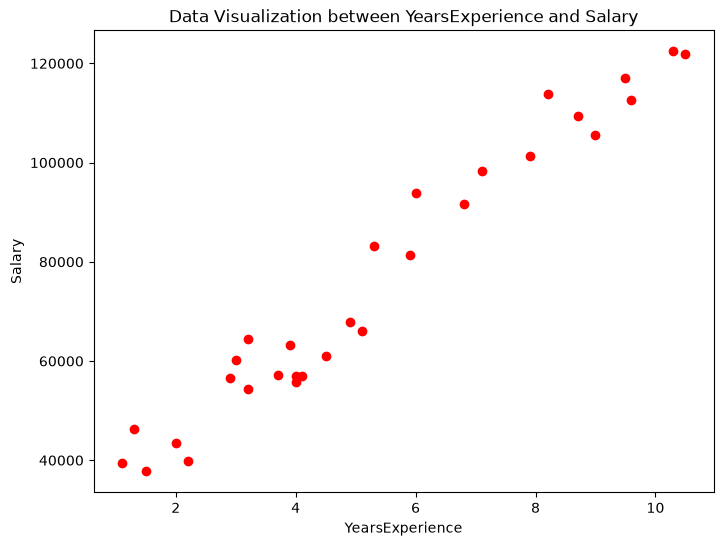

In [980]:
plt.figure(figsize=(8,6))
plt.scatter(df['YearsExperience'],df['Salary'],color='red')
plt.title('Data Visualization between YearsExperience and Salary')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.show()

##### OBSERVATIONS:

1.  The above graph depcits about the linear relationship between YearsExperience and Salary.

2.  With the increase in YearsExperience , the salary earned by the employee also increases.

##### Step 5: Perform Data Cleaning

In [981]:
##### To check if the dataset has any NULL records in it
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

##### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [982]:
##### To check if the dataset has any duplicate records in it
df[df.duplicated()]

,YearsExperience,Salary


##### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

##### Step 6: Perform EDA

                 YearsExperience    Salary
YearsExperience         1.000000  0.978242
Salary                  0.978242  1.000000


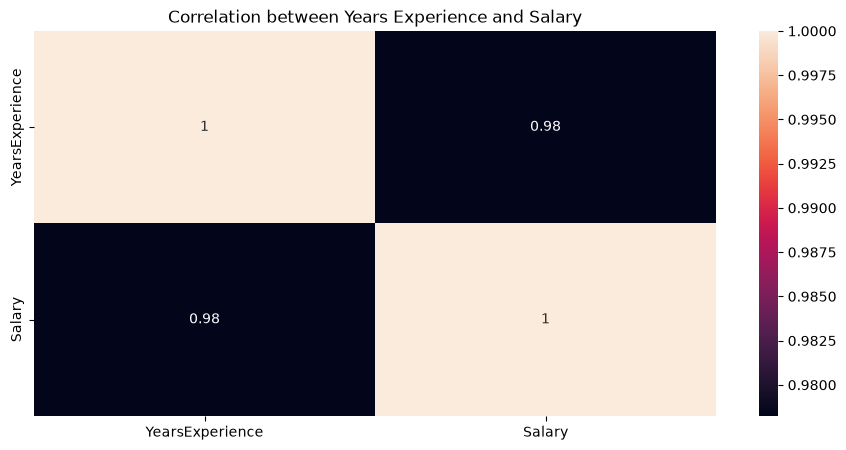

In [983]:
#### To find out the correlation between Years Experience and Salary and depict it graphically

correlation = df.corr()
print(correlation)

##### Graphically depict the correlation between Years Experience and Salary
plt.figure(figsize=(11,5))
sns.heatmap(correlation, annot=True)
plt.title('Correlation between Years Experience and Salary')
plt.show()

##### OBSERVATIONS:

1.  The above graph explains the correlation between YearsExperience and Salary.

2.  The correlation between YearsExperience and Salary is very high around 0.98

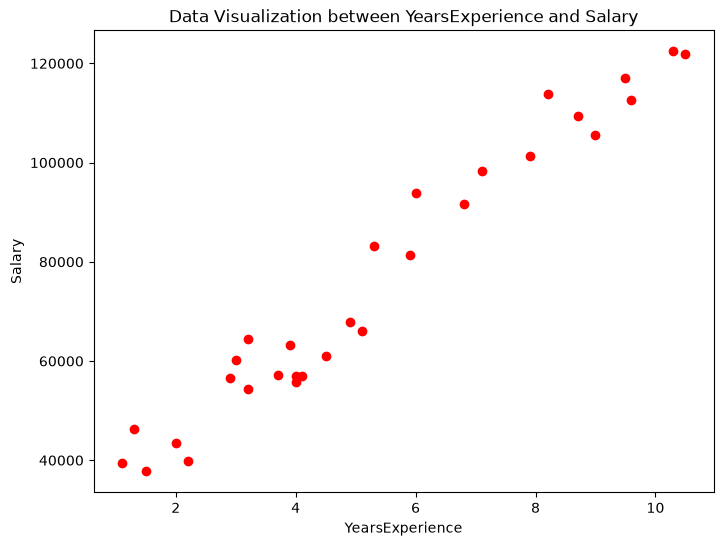

In [984]:
##### To display the visualization between YearsExperience and Salary

plt.figure(figsize=(8,6))
plt.scatter(df['YearsExperience'],df['Salary'],color='red')
plt.title('Data Visualization between YearsExperience and Salary')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.show()

##### OBSERVATIONS:

1.  With the increase in the YearsExperience, the salary of an employee also increases.

##### Step 7: Define the Independent and dependent variable

In [985]:
##### Independent variable
X = df[['YearsExperience']]

#### dependent variable
Y = df['Salary']

In [986]:
print(X)

    YearsExperience
0               1.1
1               1.3
2               1.5
3               2.0
4               2.2
5               2.9
6               3.0
7               3.2
8               3.2
9               3.7
10              3.9
11              4.0
12              4.0
13              4.1
14              4.5
15              4.9
16              5.1
17              5.3
18              5.9
19              6.0
20              6.8
21              7.1
22              7.9
23              8.2
24              8.7
25              9.0
26              9.5
27              9.6
28             10.3
29             10.5


In [987]:
print(Y)

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64


##### Step 8: Perform Train test split operation

In [988]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [989]:
X_train

,YearsExperience
28,10.3
24,8.7
12,4.0
0,1.1
4,2.2
16,5.1
5,2.9
13,4.1
11,4.0
22,7.9


In [990]:
X_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [991]:
print("Shape of the input training data is", X_train.shape)
print("Shape of the input testing  data is", X_test.shape)

Shape of the input training data is (24, 1)
Shape of the input testing  data is (6, 1)


In [992]:
Y_train

28    122391.0
24    109431.0
12     56957.0
0      39343.0
4      39891.0
16     66029.0
5      56642.0
13     57081.0
11     55794.0
22    101302.0
1      46205.0
2      37731.0
25    105582.0
3      43525.0
21     98273.0
26    116969.0
18     81363.0
29    121872.0
20     91738.0
7      54445.0
10     63218.0
14     61111.0
19     93940.0
6      60150.0
Name: Salary, dtype: float64

In [993]:
Y_test

27    112635.0
15     67938.0
23    113812.0
17     83088.0
8      64445.0
9      57189.0
Name: Salary, dtype: float64

In [994]:
print("Shape of the output training data is", Y_train.shape)
print("Shape of the output testing  data is", Y_test.shape)

Shape of the output training data is (24,)
Shape of the output testing  data is (6,)


##### Step 9: Create a Linear Regression Model

In [995]:
from sklearn.linear_model import LinearRegression

##### Create an object for Linear Regression
lin = LinearRegression()

##### OBSERVATIONS:

1.  The object of linear regression has been made.

##### Step 10: Train the model

In [996]:
##### using the object of linear regression,train the model
lin.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.532e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


##### OBSERVATIONS:

1.  The linear regression model has been trained using the training data.

##### Step 11: Find the slope and intercept from the model

In [997]:
slope = lin.coef_[0]
print(f'Slope of the model is {slope}')

##### Get the intercept of the model
intercept = lin.intercept_
print(f'Intercept of the model is {intercept}')

Slope of the model is 9423.815323030976
Intercept of the model is 25321.583011776813


##### Step 12: Make the manual predictions

In [998]:
x = 1.1

m = 9423.815323030976

c = 25321.583011776813

##### Get the predicted outputfor it
Y_pred_sample = (m*x)+c
print(f'Predicted output for the sample data is {Y_pred_sample}')

Predicted output for the sample data is 35687.77986711089


In [999]:
print(f'Actual output for the same data is {df.iloc[[0]]}')

Actual output for the same data is    YearsExperience   Salary
0              1.1  39343.0


##### Step 13: Make the predictions for the model

In [1000]:
X_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [1001]:
Y_test

27    112635.0
15     67938.0
23    113812.0
17     83088.0
8      64445.0
9      57189.0
Name: Salary, dtype: float64

In [1002]:
Y_pred = lin.predict(X_test)
print(Y_pred)

[115790.21011287  71498.27809463 102596.86866063  75267.80422384
  55477.79204548  60189.69970699]


##### Step 14: Make the dataframe for the predicted output and the actual output and find out the residuals

In [1003]:
##### Construct the new dataframe for showing the results
df_new = pd.DataFrame({
    'YearsExperience'       :       X_test["YearsExperience"]                       ,
    'ActualSalary'          :       Y_test                                          ,
    'PredictedSalary'       :       Y_pred                                          ,
    'Residuals'             :       (Y_test - Y_pred)
})

In [1004]:
df_new

,YearsExperience,ActualSalary,PredictedSalary,Residuals
27,9.6,112635.0,115790.210113,-3155.210113
15,4.9,67938.0,71498.278095,-3560.278095
23,8.2,113812.0,102596.868661,11215.131339
17,5.3,83088.0,75267.804224,7820.195776
8,3.2,64445.0,55477.792045,8967.207955
9,3.7,57189.0,60189.699707,-3000.699707


##### OBSERVATIONS:

1.  The above dataframe shows the years experience, actual and predicted salary and the difference between them.

##### Step 15: Evaluate the Model

In [1005]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

mae = mean_absolute_error(Y_test, Y_pred)
print(f'Mean Absolute error of the model is {mae}')

mse = mean_squared_error(Y_test, Y_pred)
print(f'Mean Squared error of the model is {mse}')

rmse = root_mean_squared_error(Y_test, Y_pred)
print(f'Root Mean Squared error of the model is {rmse}')

r2 = r2_score(Y_test, Y_pred)
print(f'R2 Score of the model is {r2}')

Mean Absolute error of the model is 6286.453830757749
Mean Squared error of the model is 49830096.85590839
Root Mean Squared error of the model is 7059.04362190151
R2 Score of the model is 0.9024461774180497


##### OBSERVATIONS:

1.  Here from the above evaluation of the model, we see that the accuracy(r2) score of the model is 0.90 which is very high. So the model is working fine.

##### Step 16: Visualize the Regression Line

(a.) training data

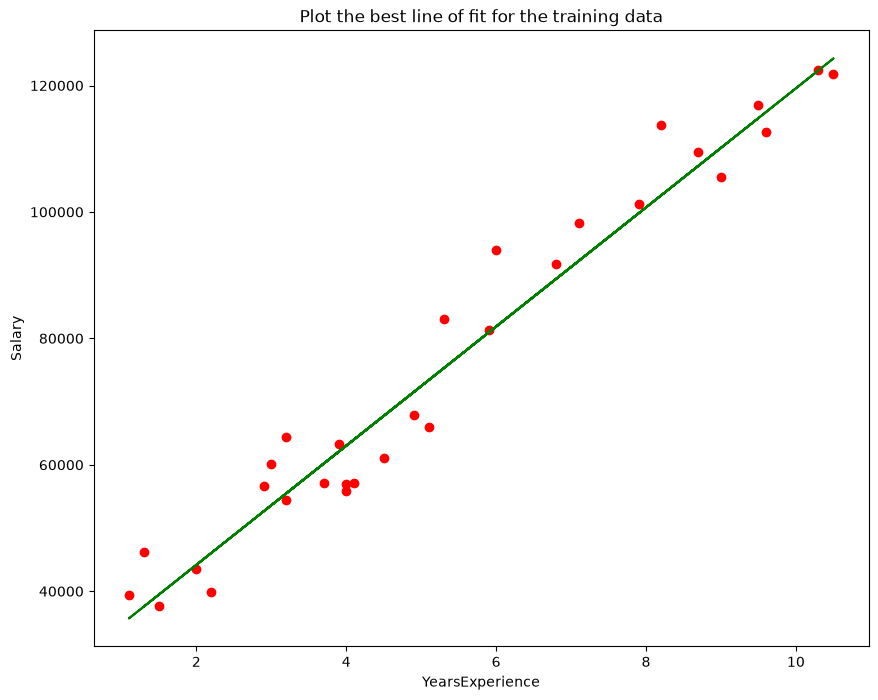

In [1006]:
plt.figure(figsize=(10,8))
plt.scatter(df['YearsExperience'], df['Salary'], color='red')
##### Plot the best fit of line
plt.plot(X_train,lin.predict(X_train),color='green')
##### Get the title of the graph
plt.title('Plot the best line of fit for the training data')
##### Get the x-axis of the graph
plt.xlabel('YearsExperience')
##### Get the y-axis of the graph
plt.ylabel('Salary')
plt.show()

(b.) testing data

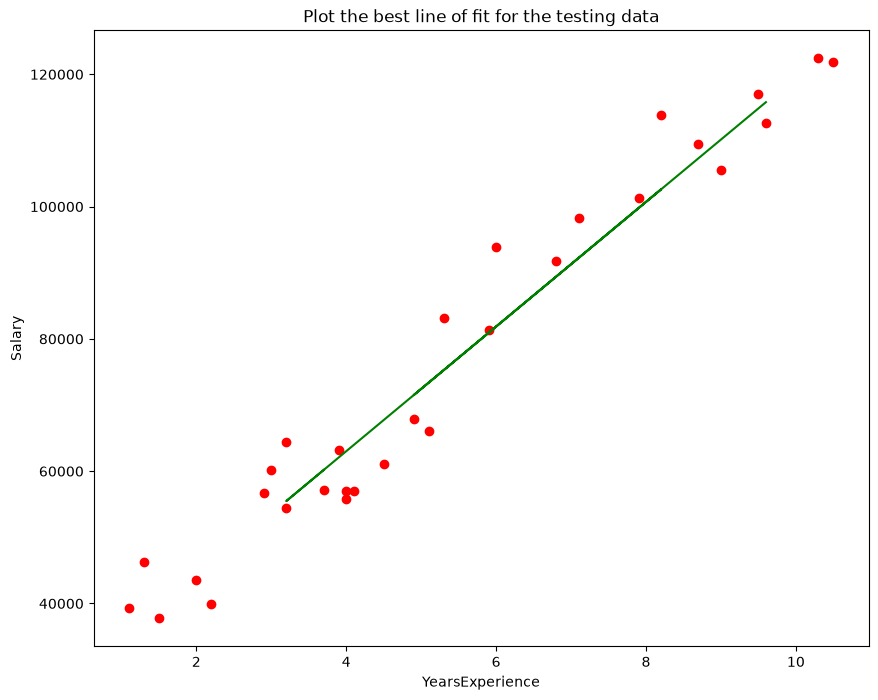

In [1007]:
plt.figure(figsize=(10,8))
plt.scatter(df['YearsExperience'], df['Salary'], color='red')
##### Plot the best fit of line
plt.plot(X_test,lin.predict(X_test),color='green')
##### Get the title of the graph
plt.title('Plot the best line of fit for the testing data')
##### Get the x-axis of the graph
plt.xlabel('YearsExperience')
##### Get the y-axis of the graph
plt.ylabel('Salary')
plt.show()

##### OBSERVATIONS:

1.  From the above graphs, in both the cases we see that the best fit of line passes through the training and testing data in both the cases.

2.  So the accuracy(R2 score) of the model in both the cases is very high.

##### Step 17: Predict the salary for a new employee

In [1008]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [1009]:
new_employee_1 = pd.DataFrame({
    'YearsExperience'   :   [5.0]
})

new_employee_1


##### predict the salary for 5 years of experience
predicted_salary_5 = lin.predict(new_employee_1)
print(predicted_salary_5)

[72440.65962693]


In [1010]:
new_employee_2 = pd.DataFrame({
    'YearsExperience'       :   [7.0]
})

new_employee_2

##### predict the salary for 7 years of experience
predicted_salary_7 = lin.predict(new_employee_2)
print(predicted_salary_7)

[91288.29027299]


##### Step 18: Save the model

In [1011]:
import joblib

##### Dump and save the model in a pickle file
joblib.dump(lin,"linear_salary_regression.pkl")

['linear_salary_regression.pkl']